<a href="https://colab.research.google.com/github/Disha-Nagaraja-git/1BM23AI062-AAL-Lab-Programs/blob/main/SNA_AAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Social Network Analysis of Public Transport Connectivity for Sustainable Cities

## Bengaluru BMTC Case Study aligned with SDG 11

**Course:** Social Network Analysis (SNA)

**Project:** Alternative Assessment Tool (AAT)

**Dataset:** BMTC GTFS dataset from the Vonter/bmtc-gtfs repository

### Network Interpretation

- **Node:** BMTC bus stop
- **Edge:** Direct consecutive-stop connection within a trip
- **Network:** Bengaluru BMTC public transport connectivity network
- **Link Prediction:** Predict potentially useful missing connections between stops
- **Sustainability Context:** SDG 11 - Sustainable Cities and Communities

1. Import Libraries

In [13]:
import os
import math
import random
import zipfile
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

random.seed(42)
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


2. Upload the BMTC Dataset
Upload the bmtc-gtfs-main.zip file downloaded from the GitHub repository.
The repository ZIP contains an inner file:
gtfs/bmtc.zip
The inner GTFS file contains the files needed for this project, including:
- stops.txt
- stop_times.txt
- trips.txt
- routes.txt

In [15]:
uploaded = files.upload()

uploaded_name = next(iter(uploaded))
print("Uploaded:", uploaded_name)

Saving bmtc-gtfs-main.zip to bmtc-gtfs-main (1).zip
Uploaded: bmtc-gtfs-main (1).zip


3. Extract the GTFS Dataset

In [16]:
# Create working directories
WORK_DIR = Path("/content/bmtc_project")
OUTER_DIR = WORK_DIR / "repository"
GTFS_DIR = WORK_DIR / "gtfs"

WORK_DIR.mkdir(exist_ok=True)
OUTER_DIR.mkdir(exist_ok=True)
GTFS_DIR.mkdir(exist_ok=True)

# Extract the uploaded repository ZIP
with zipfile.ZipFile(uploaded_name, "r") as z:
    z.extractall(OUTER_DIR)

# Find the nested GTFS ZIP
nested_zips = list(OUTER_DIR.rglob("bmtc.zip"))

if not nested_zips:
    raise FileNotFoundError("Could not find gtfs/bmtc.zip inside the uploaded repository.")

nested_gtfs_zip = nested_zips[0]
print("Found GTFS ZIP:", nested_gtfs_zip)

# Extract the GTFS ZIP
with zipfile.ZipFile(nested_gtfs_zip, "r") as z:
    z.extractall(GTFS_DIR)

print("GTFS extraction completed.")
print("Files:")
for p in sorted(GTFS_DIR.iterdir()):
    print(" -", p.name)

Found GTFS ZIP: /content/bmtc_project/repository/bmtc-gtfs-main/gtfs/bmtc.zip
GTFS extraction completed.
Files:
 - agency.txt
 - attributions.txt
 - calendar.txt
 - fare_attributes.txt
 - fare_rules.txt
 - feed_info.txt
 - routes.txt
 - shapes.txt
 - stop_times.txt
 - stops.txt
 - translations.txt
 - trips.txt


4. Load the BMTC GTFS Files

In [17]:
stops = pd.read_csv(GTFS_DIR / "stops.txt")
stop_times = pd.read_csv(GTFS_DIR / "stop_times.txt")
trips = pd.read_csv(GTFS_DIR / "trips.txt")
routes = pd.read_csv(GTFS_DIR / "routes.txt")

print("Stops:", stops.shape)
print("Stop times:", stop_times.shape)
print("Trips:", trips.shape)
print("Routes:", routes.shape)

Stops: (9960, 9)
Stop times: (1540686, 6)
Trips: (57836, 6)
Routes: (4434, 5)


In [18]:
print("STOPS")
display(stops.head())

print("STOP TIMES")
display(stop_times.head())

print("TRIPS")
display(trips.head())

print("ROUTES")
display(routes.head())

STOPS


,stop_name,parent_station,zone_id,stop_id,stop_desc,stop_lat,stop_lon,location_type,platform_code
0,12th Block Nagarabhavi,NaN,NBV12B,21629,12th Block Nagarabhavi (Towards AIT College),12.96018,77.51398,NaN,NaN
1,12th Block Nagarabhavi,NaN,NBV12B,21630,12th Block Nagarabhavi (Towards Nagarabhavi Ci...,12.96076,77.51351,NaN,NaN
2,14th Main HSR Layout,NaN,HSR14,20568,14th Main HSR Layout (Towards Hebbala),12.91637,77.63472,NaN,NaN
3,18th Main Jayanagara,NaN,JNR18,22890,18th Main Jayanagara (Towards Jayanagara 4th B...,12.92328,77.58898,NaN,NaN
4,19th Main 13th Cross HSR Layout,NaN,HSR13th,22891,19th Main 13th Cross HSR Layout (Towards Paran...,12.91593,77.65176,NaN,NaN


STOP TIMES


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign
0,34340,17:45:00,17:45:00,27263,1,2nd Stage 9th Block Nagarabhavi
1,34340,17:47:15,17:47:15,20985,2,2nd Stage 9th Block Nagarabhavi
2,34340,17:55:04,17:55:04,20921_PF5,3,2nd Stage 9th Block Nagarabhavi
3,34340,17:58:31,17:58:31,35387,4,2nd Stage 9th Block Nagarabhavi
4,34340,18:01:46,18:01:46,21200,5,2nd Stage 9th Block Nagarabhavi


TRIPS


,route_id,service_id,trip_headsign,direction_id,shape_id,trip_id
0,1000,1,Chandapura,0,KBS-3C UP,1093
1,1000,1,Chandapura,0,KBS-3C UP,1094
2,1000,1,Chandapura,0,KBS-3C UP,1095
3,1000,1,Chandapura,0,KBS-3C UP,1096
4,1000,1,Chandapura,0,KBS-3C UP,1097


ROUTES


,route_long_name,route_short_name,agency_id,route_type,route_id
0,2nd Stage 9th Block Nagarabhavi ⇔ Shivajinagar...,244-C VSD,1,3,3447
1,5th Block HBR Layout ⇔ Kalyananagara Bus Stand,KLN-HBR,1,3,7041
2,5th Block HBR Layout ⇔ Kempegowda Bus Station,296,1,3,2712
3,5th Block HBR Layout ⇔ Kempegowda Bus Station,296-B,1,3,4821
4,5th Block HBR Layout ⇔ Shivajinagara Bus Station,296-D,1,3,2809


5. Dataset Preprocessing
We use:
- stops.txt for stop identity, names and coordinates.
- stop_times.txt to determine the order of stops within each trip.
- trips.txt for trip information.
- routes.txt for route information.
For the SNA graph, the most important relationship is:
Trip → ordered stops → consecutive stop connections

In [19]:
# Keep only the columns needed for the network
stops = stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]].copy()
stop_times = stop_times[["trip_id", "stop_id", "stop_sequence"]].copy()

# Convert identifiers to strings
stops["stop_id"] = stops["stop_id"].astype(str)
stop_times["stop_id"] = stop_times["stop_id"].astype(str)
stop_times["trip_id"] = stop_times["trip_id"].astype(str)

# Convert sequence to numeric
stop_times["stop_sequence"] = pd.to_numeric(
    stop_times["stop_sequence"], errors="coerce"
)

# Remove missing values
stops = stops.dropna(subset=["stop_id", "stop_name"])
stop_times = stop_times.dropna(
    subset=["trip_id", "stop_id", "stop_sequence"]
)

# Remove duplicate stop definitions and duplicate stop-time records
stops = stops.drop_duplicates(subset=["stop_id"])
stop_times = stop_times.drop_duplicates(
    subset=["trip_id", "stop_id", "stop_sequence"]
)

# Sort by trip and stop order
stop_times = stop_times.sort_values(
    ["trip_id", "stop_sequence"]
).reset_index(drop=True)

print("Clean stops:", len(stops))
print("Clean stop-time records:", len(stop_times))

Clean stops: 9960
Clean stop-time records: 1540686


6. Construct the Public Transport Network
Node = bus stop
Edge = two consecutive stops appearing in the same trip
The graph is treated as undirected for the basic SNA and link-prediction experiment because we are studying overall connectivity between stops rather than direction-specific travel.

In [20]:
# Create consecutive stop pairs for each trip
edges = []

for trip_id, group in stop_times.groupby("trip_id", sort=False):
    stop_list = group["stop_id"].tolist()

    if len(stop_list) < 2:
        continue

    edges.extend(zip(stop_list[:-1], stop_list[1:]))

edges_df = pd.DataFrame(edges, columns=["source", "target"])

# Remove self-loops and duplicate connections
edges_df = edges_df[
    edges_df["source"] != edges_df["target"]
].drop_duplicates().reset_index(drop=True)

print("Unique transport connections:", len(edges_df))
display(edges_df.head(10))

Unique transport connections: 17668


,source,target
0,20921_PF5,20603
1,20603,35303
2,35303,20702
3,20702,20990
4,20990,20751
5,20751,20810
6,20810,21007
7,21007,21049
8,21049,21027
9,21027,21164


In [21]:
# Build the graph
G = nx.Graph()

G.add_nodes_from(stops["stop_id"])
G.add_edges_from(
    edges_df[["source", "target"]].itertuples(index=False, name=None)
)

# Remove isolated stops for the main connectivity analysis
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

print("Total connected nodes:", G.number_of_nodes())
print("Total edges:", G.number_of_edges())
print("Isolated stops removed:", len(isolated))

Total connected nodes: 9948
Total edges: 16788
Isolated stops removed: 12


7. Largest Connected Component
For centrality and link-prediction analysis, we use the largest connected component so that the network represents one connected public-transport structure.

In [22]:
largest_component_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_component_nodes).copy()

print("Largest connected component nodes:", G.number_of_nodes())
print("Largest connected component edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 6))

Largest connected component nodes: 9860
Largest connected component edges: 16727
Density: 0.000344


8. Basic Network Analysis

In [23]:
# Stop-name lookup
stop_name_map = dict(zip(stops["stop_id"], stops["stop_name"]))

# Degree
degree_df = pd.DataFrame(
    list(G.degree()),
    columns=["stop_id", "degree"]
)
degree_df["stop_name"] = degree_df["stop_id"].map(stop_name_map)
degree_df = degree_df.sort_values("degree", ascending=False)

print("Top 10 most connected stops:")
display(degree_df.head(10))

Top 10 most connected stops:


,stop_id,degree,stop_name
5076,36441,26,Kalyananagara Bus Stand
1600,35759,26,CS-BEL Factory
1674,36747,25,CS-HAL ARDC
5402,20922,24,Kempegowda Bus Station
1601,35746,24,CS-BEML Factory
5401,20921,24,Kempegowda Bus Station
7376,21071,22,Okalipura
1593,36456,21,CS-Army Public School Kamaraja Road
7378,35387,20,Okalipura
1679,36231,20,CS-Head Start School Kommasandra


In [24]:
# Degree centrality
degree_centrality = nx.degree_centrality(G)

degree_centrality_df = pd.DataFrame(
    list(degree_centrality.items()),
    columns=["stop_id", "degree_centrality"]
)
degree_centrality_df["stop_name"] = (
    degree_centrality_df["stop_id"].map(stop_name_map)
)
degree_centrality_df = degree_centrality_df.sort_values(
    "degree_centrality", ascending=False
)

print("Top 10 by degree centrality:")
display(degree_centrality_df.head(10))

Top 10 by degree centrality:


,stop_id,degree_centrality,stop_name
5076,36441,0.002637,Kalyananagara Bus Stand
1600,35759,0.002637,CS-BEL Factory
1674,36747,0.002536,CS-HAL ARDC
5402,20922,0.002434,Kempegowda Bus Station
1601,35746,0.002434,CS-BEML Factory
5401,20921,0.002434,Kempegowda Bus Station
7376,21071,0.002231,Okalipura
1593,36456,0.002130,CS-Army Public School Kamaraja Road
7378,35387,0.002029,Okalipura
1679,36231,0.002029,CS-Head Start School Kommasandra


In [27]:
# Approximate betweenness centrality
# k controls how many nodes are sampled.
# Larger k = more accurate but slower.

betweenness = nx.betweenness_centrality(
    G,
    k=500,
    seed=42
)

betweenness_df = pd.DataFrame(
    list(betweenness.items()),
    columns=["stop_id", "betweenness"]
)

betweenness_df["stop_name"] = (
    betweenness_df["stop_id"].map(stop_name_map)
)

betweenness_df = betweenness_df.sort_values(
    "betweenness",
    ascending=False
)

print("Top 10 by approximate betweenness centrality:")
display(betweenness_df.head(10))

Top 10 by approximate betweenness centrality:


,stop_id,betweenness,stop_name
5402,20922,0.287691,Kempegowda Bus Station
5401,20921,0.184563,Kempegowda Bus Station
3650,20823,0.173498,Hebbala Bridge
9287,21229,0.154176,Tin Factory
4025,38887,0.150274,ISHA FOUNDATION
831,20624,0.128944,Banashankari Bus Station
6947,30392,0.103564,NICE Road Magadi Road Junction
6937,27461,0.102183,NICE Road Bannerughatta Road Junction
6632,21019,0.094161,Mekhri Circle
6951,27468,0.084494,NICE Road Mysore Road Junction


9. 80/20 Train-Test Split
We hide 20% of the observed transport connections and use the remaining 80% as the training network.
This allows us to test whether link-prediction algorithms can recover connections that were hidden from the model.

In [28]:
random.seed(42)

all_edges = list(G.edges())
random.shuffle(all_edges)

split_index = int(0.80 * len(all_edges))

train_edges = all_edges[:split_index]
test_edges = all_edges[split_index:]

G_train = nx.Graph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_edges)

print("Total edges:", len(all_edges))
print("Training edges (80%):", len(train_edges))
print("Testing edges (20%):", len(test_edges))

Total edges: 16727
Training edges (80%): 13381
Testing edges (20%): 3346


10. Negative Sampling
Negative samples are pairs of stops that are not directly connected in the training graph.
We use the same number of negative examples as positive test examples.

In [29]:
def sample_negative_edges(G, number_needed, seed=42):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    existing = {frozenset(edge) for edge in G.edges()}
    sampled = set()

    max_possible = len(nodes) * (len(nodes) - 1) // 2 - len(existing)
    number_needed = min(number_needed, max_possible)

    while len(sampled) < number_needed:
        u, v = rng.sample(nodes, 2)
        edge_key = frozenset((u, v))

        if edge_key not in existing and edge_key not in sampled:
            sampled.add(edge_key)

    return [tuple(edge) for edge in sampled]

negative_edges = sample_negative_edges(
    G_train, len(test_edges), seed=42
)

print("Positive test edges:", len(test_edges))
print("Negative test edges:", len(negative_edges))

Positive test edges: 3346
Negative test edges: 3346


11. Link-Prediction Functions
We implement the four algorithms required for the SNA AAT:
1. Common Neighbors
2. Jaccard Coefficient
3. Adamic-Adar
4. Preferential Attachment

In [30]:
def common_neighbors_score(G, u, v):
    return len(set(G.neighbors(u)) & set(G.neighbors(v)))


def jaccard_score(G, u, v):
    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))

    union = neighbors_u | neighbors_v

    if not union:
        return 0.0

    return len(neighbors_u & neighbors_v) / len(union)


def adamic_adar_score(G, u, v):
    common = set(G.neighbors(u)) & set(G.neighbors(v))
    score = 0.0

    for node in common:
        d = G.degree(node)
        if d > 1:
            score += 1 / math.log(d)

    return score


def preferential_attachment_score(G, u, v):
    return G.degree(u) * G.degree(v)


print("Link-prediction functions ready.")

Link-prediction functions ready.


12. Generate Scores for Candidate Pairs
Instead of creating every possible pair of approximately 10,000 stops, we use a practical two-hop candidate set: pairs that share at least one neighbor in the training graph.
This keeps the experiment computationally manageable while matching the intuition behind Common Neighbors, Jaccard and Adamic-Adar.

In [31]:
def generate_two_hop_candidates(G, max_candidates=100000, seed=42):
    candidates = set()

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        # Pairs of neighbors are potential two-hop connections
        for u, v in combinations(neighbors, 2):
            if u == v or G.has_edge(u, v):
                continue

            candidates.add(tuple(sorted((u, v))))

            if len(candidates) >= max_candidates:
                return list(candidates)

    return list(candidates)

candidate_edges = generate_two_hop_candidates(
    G_train, max_candidates=100000, seed=42
)

# Make sure hidden positive test edges are available for evaluation
candidate_set = set(candidate_edges)

for edge in test_edges:
    edge = tuple(sorted(edge))
    candidate_set.add(edge)

candidate_edges = list(candidate_set)

print("Candidate pairs:", len(candidate_edges))

Candidate pairs: 33927


In [32]:
def calculate_predictions(G, candidate_edges):
    results = []

    for u, v in candidate_edges:
        results.append([
            u,
            v,
            common_neighbors_score(G, u, v),
            jaccard_score(G, u, v),
            adamic_adar_score(G, u, v),
            preferential_attachment_score(G, u, v)
        ])

    return pd.DataFrame(
        results,
        columns=[
            "source",
            "target",
            "common_neighbors",
            "jaccard",
            "adamic_adar",
            "preferential_attachment"
        ]
    )

prediction_df = calculate_predictions(
    G_train, candidate_edges
)

print("Prediction table created.")
display(prediction_df.head())

Prediction table created.


,source,target,common_neighbors,jaccard,adamic_adar,preferential_attachment
0,20815,20998,1,0.142857,0.558111,15
1,22225,24269,1,0.142857,0.621335,15
2,25997,34853,1,0.166667,0.721348,10
3,20944_PF4,20967,2,0.181818,0.779742,30
4,32283,35660,1,0.333333,0.721348,4


13. Top-10 Predicted Transport Connections

In [33]:
def add_stop_names(df):
    df = df.copy()
    df["source_name"] = df["source"].map(stop_name_map)
    df["target_name"] = df["target"].map(stop_name_map)
    return df

top10_cn = add_stop_names(
    prediction_df.sort_values("common_neighbors", ascending=False).head(10)
)

top10_jaccard = add_stop_names(
    prediction_df.sort_values("jaccard", ascending=False).head(10)
)

top10_aa = add_stop_names(
    prediction_df.sort_values("adamic_adar", ascending=False).head(10)
)

top10_pa = add_stop_names(
    prediction_df.sort_values(
        "preferential_attachment", ascending=False
    ).head(10)
)

print("Top 10 - Common Neighbors")
display(top10_cn[["source_name", "target_name", "common_neighbors"]])

print("Top 10 - Jaccard")
display(top10_jaccard[["source_name", "target_name", "jaccard"]])

print("Top 10 - Adamic-Adar")
display(top10_aa[["source_name", "target_name", "adamic_adar"]])

print("Top 10 - Preferential Attachment")
display(top10_pa[
    ["source_name", "target_name", "preferential_attachment"]
])

Top 10 - Common Neighbors


,source_name,target_name,common_neighbors
29439,Maharani College,Mysore Bank,8
33718,Kempegowda Bus Station,Kempegowda Bus Station - Platform 5,7
2714,Yeshawanthapura Bus Station,Yeshawanthapura Bus Station - Platform 2,7
3980,Sangam Circle,Sangam Circle,7
22120,Indian Express,Indian Express,7
16277,ITI Colony Gate,ITI Colony Gate,7
26887,Banashankari Bus Station,Banashankari Bus Station - Platform 5,7
15734,Tavarekere,Tavarekere,7
7829,Tavarekere,Tavarekere,6
17469,Kadirenahalli Cross,Sangam Circle,6


Top 10 - Jaccard


,source_name,target_name,jaccard
9169,Chinthala Madivala,Gattahalli,1.0
26700,CS-Ejipura,CS-CMP Centre and School,1.0
24166,Kadanuru Katte,Kadanuru Katte,1.0
26728,CS-KR Puram Railway Station,CS-5th Block HBR Layout,1.0
18851,CS-Maligondanahalli,CS-Chandrappa Circle,1.0
18909,Kerekodi Thyamagondlu,Kerekodi Thyamagondlu,1.0
28661,KR Market,KR Market Flyover,1.0
14147,Kempegowda Bus Station - Platform 1,Kempegowda Bus Station - Platform 3,1.0
28677,Water Tank,Kumaraswamy Layout 2nd Stage,1.0
24187,CS-People Tree Hospital Nagendra Block,CS-Hennur Junction,1.0


Top 10 - Adamic-Adar


,source_name,target_name,adamic_adar
7512,Okalipura,Okalipura,7.559451
29439,Maharani College,Mysore Bank,6.811560
15734,Tavarekere,Tavarekere,4.856505
14264,Central,KPCC Office,4.687408
16816,Makkala Koota,Makkala Koota,4.607707
17187,Bidarahalli Cross,Bidarahalli Cross,4.516977
24205,Vivekananda Vidyavardhaka School,Vivekananda Vidyavardhaka School,4.465419
25479,BEML Gate,BEML Gate,4.416964
29691,Devanahalli New Bus Station,Devanahalli New Bus Station,4.416964
5715,Nagaruru Cross,Nagaruru Cross,4.328085


Top 10 - Preferential Attachment


,source_name,target_name,preferential_attachment
6171,CS-BEL Factory,CS-HAL ARDC,378
23733,CS-BEL Factory,CS-Head Start School Kommasandra,378
26455,Kempegowda Bus Station,Kempegowda Bus Station,288
8308,Banashankari Bus Station,Maharani College,272
12681,Banashankari Bus Station,Central,255
104,Banashankari Bus Station,Banashankari Bus Station,255
27273,Maharani College,Okalipura,240
23880,Central,Maharani College,240
8596,Kempegowda Bus Station,Okalipura,240
29439,Maharani College,Mysore Bank,240


14. Evaluation Dataset
Positive examples are the hidden 20% test edges.
Negative examples are sampled non-edges from the training network.

In [34]:
positive_edges = [tuple(sorted(edge)) for edge in test_edges]
negative_edges_sorted = [tuple(sorted(edge)) for edge in negative_edges]

evaluation_edges = positive_edges + negative_edges_sorted
y_true = (
    [1] * len(positive_edges)
    + [0] * len(negative_edges_sorted)
)

evaluation_df = calculate_predictions(
    G_train, evaluation_edges
)

print("Evaluation examples:", len(evaluation_df))

Evaluation examples: 6692


15. Evaluation Metrics
We calculate:
- Precision
- Recall
- F1-score
- ROC-AUC
- Precision@10

In [35]:
def precision_at_k(y_true, scores, k=10):
    k = min(k, len(scores))
    ranked_indices = np.argsort(np.asarray(scores))[::-1][:k]
    top_labels = np.asarray(y_true)[ranked_indices]
    return float(np.mean(top_labels))


algorithms = [
    "common_neighbors",
    "jaccard",
    "adamic_adar",
    "preferential_attachment"
]

evaluation_results = []

for algorithm in algorithms:
    scores = evaluation_df[algorithm].to_numpy()

    # Threshold at the median score for binary classification
    threshold = np.median(scores)
    y_pred = (scores >= threshold).astype(int)

    precision = precision_score(
        y_true, y_pred, zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )
    roc_auc = roc_auc_score(
        y_true, scores
    )
    p_at_10 = precision_at_k(
        y_true, scores, k=10
    )

    evaluation_results.append([
        algorithm,
        precision,
        recall,
        f1,
        roc_auc,
        p_at_10
    ])

results_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Algorithm",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Precision@10"
    ]
)

display(results_df.round(4))

,Algorithm,Precision,Recall,F1,ROC-AUC,Precision@10
0,common_neighbors,0.5000,1.0000,0.6667,0.6194,1.0
1,jaccard,0.5000,1.0000,0.6667,0.6194,1.0
2,adamic_adar,0.5000,1.0000,0.6667,0.6194,1.0
3,preferential_attachment,0.4926,0.4943,0.4934,0.4927,1.0


16. Visualize the BMTC Network
The full BMTC network has thousands of nodes, so a complete labelled plot can become cluttered.
We therefore visualize the largest connected network without labels. A smaller subgraph can be used for a clearer PPT figure.

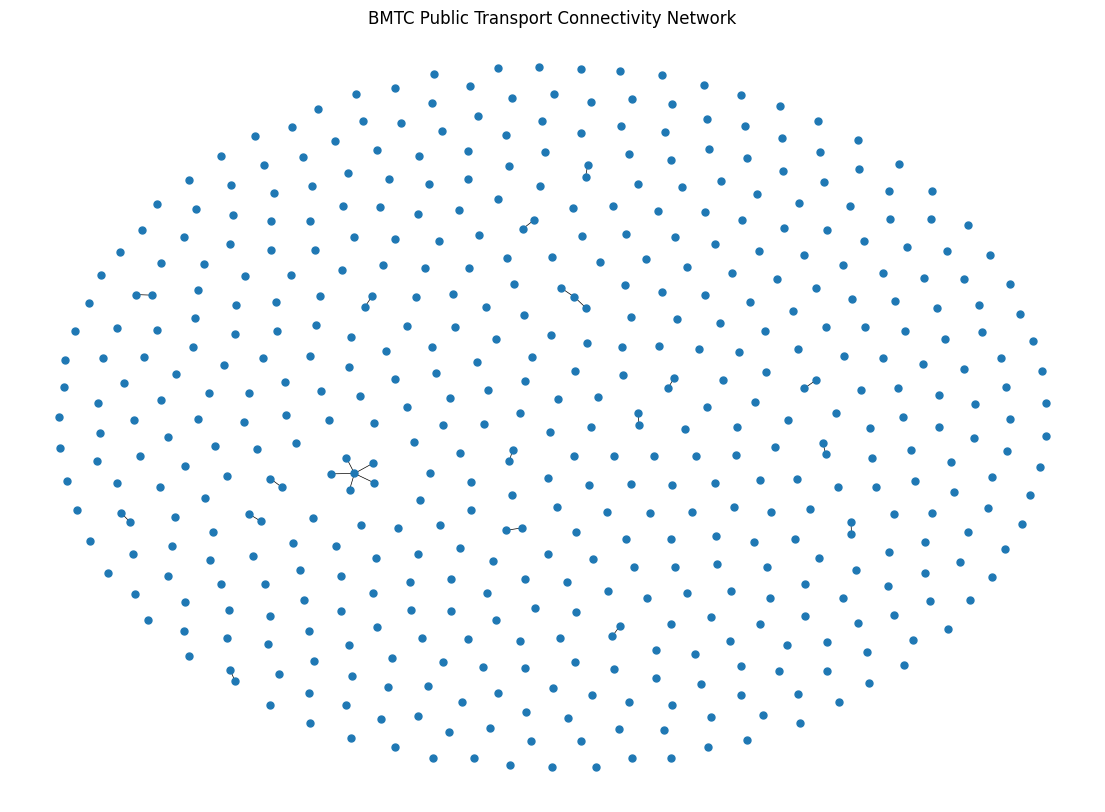

In [37]:
plt.figure(figsize=(14, 10))

# Spring layout can be expensive on very large graphs.
# Use a sample of up to 500 nodes for a clear visualization.
visual_nodes = list(G_train.nodes())

if len(visual_nodes) > 500:
    rng = random.Random(42)
    visual_nodes = rng.sample(visual_nodes, 500)

H = G_train.subgraph(visual_nodes).copy()

pos = nx.spring_layout(H, seed=42)

nx.draw_networkx(
    H,
    pos,
    with_labels=False,
    node_size=25,
    width=0.5
)

plt.title("BMTC Public Transport Connectivity Network")
plt.axis("off")
plt.show()

17. Export Results
These files can be used for the Word report, PPT and Cytoscape.

In [38]:
RESULT_DIR = WORK_DIR / "results"
VIS_DIR = WORK_DIR / "visualizations"

RESULT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

edges_df.to_csv(
    RESULT_DIR / "bmtc_transport_edges.csv",
    index=False
)

degree_df.to_csv(
    RESULT_DIR / "degree_analysis.csv",
    index=False
)

degree_centrality_df.to_csv(
    RESULT_DIR / "degree_centrality.csv",
    index=False
)

betweenness_df.to_csv(
    RESULT_DIR / "betweenness_centrality.csv",
    index=False
)

prediction_df.to_csv(
    RESULT_DIR / "link_prediction_results.csv",
    index=False
)

results_df.to_csv(
    RESULT_DIR / "algorithm_comparison.csv",
    index=False
)

nx.write_graphml(
    G_train,
    WORK_DIR / "bmtc_network_for_cytoscape.graphml"
)

print("Results exported to:", RESULT_DIR)
print("Cytoscape file:", WORK_DIR / "bmtc_network_for_cytoscape.graphml")

Results exported to: /content/bmtc_project/results
Cytoscape file: /content/bmtc_project/bmtc_network_for_cytoscape.graphml


18. SDG 11 Interpretation
The project is aligned with SDG 11 - Sustainable Cities and Communities because public-transport connectivity is an important part of accessible and sustainable urban mobility.
The network analysis identifies highly connected stops, important intermediary stops, and potential missing connections. These results can be interpreted as analytical support for improving connectivity in an urban public-transport network.
Important project limitation
The BMTC dataset used here is an unofficial community GTFS dataset. Dataset limitations should be acknowledged in the final report, and predictions should be described as analytical suggestions, not guaranteed infrastructure recommendations.

19. Conclusion
This project models the Bengaluru BMTC public-transport system as a network where bus stops are nodes and consecutive stops are edges. Social Network Analysis is then used to study connectivity and identify important stops. Link-prediction algorithms - Common Neighbors, Jaccard, Adamic-Adar and Preferential Attachment - are compared using Precision, Recall, F1, ROC-AUC and Precision@10. The predicted links provide potential areas for further investigation in the context of sustainable urban mobility and SDG 11.

References
1. Vonter. BMTC GTFS GitHub repository.
2. Google. General Transit Feed Specification (GTFS) documentation.
3. B.M.S. College of Engineering. Social Network Analysis Course Plan, 24AM7PESNA, Semester VII.
4. Easley, D. and Kleinberg, J. Networks, Crowds, and Markets.